In [1]:
# Import Libraries
from pathlib import Path 

import pandas as pd 
import numpy as np
import lasio
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split

In [2]:
# Input and output paths
ROOT      = Path().resolve().parent
RAW       = ROOT / 'data' / 'raw'
PROCESSED = ROOT / 'data' / 'processed' 
PROCESSED.mkdir(parents=True, exist_ok=True)

In [3]:
# Load well log data from LAS files and save as CSV
well_names = ["BLT-01", "EVD-01", "JUT-01", "PKP-01"]

for name in well_names:
    las = lasio.read(RAW / f"{name}.las")
    df = las.df().reset_index()
    df.to_csv(PROCESSED  / f"{name}log.csv", index=False)

In [4]:
# Load raw target lithologies data
raw_data = pd.read_csv(RAW / "target_lithologies.csv")
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3455 entries, 0 to 3454
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   well_id                3455 non-null   str    
 1   easting                3455 non-null   float64
 2   northing               3455 non-null   float64
 3   depth_tvd_m            0 non-null      float64
 4   porosity_pct           2419 non-null   float64
 5   gamma_ray_api          3455 non-null   float64
 6   bulk_density_gcc       3199 non-null   float64
 7   formation_top_tvd      3455 non-null   float64
 8   formation_base_tvd     3455 non-null   float64
 9   formation_thickness_m  3455 non-null   float64
 10  distance_to_usp_km     3455 non-null   float64
 11  flag                   3455 non-null   str    
 12  flag_reason            3455 non-null   str    
dtypes: float64(10), str(3)
memory usage: 351.0 KB


## Checking 'well_id'

In [5]:
df = raw_data.copy() 
df['well_id'].value_counts()

well_id
BLT-01    1689
EVD-01     780
PKP-01     730
JUT-01     256
Name: count, dtype: int64

## Checking empty rows

In [6]:
# 'depth_tvd_m'
missing_rows = df[df['depth_tvd_m'].isna()].groupby('well_id').size()
if missing_rows.empty:
    print('\nNo missing rows') 
else:
    print("\nMissing depth_tvd_m counts per well:")
    print(missing_rows)

# 'porosity_pct'
missing_rows = df[df['porosity_pct'].isna()].groupby('well_id').size()
if missing_rows.empty:
    print('\nNo missing rows') 
else:
    print("\nMissing porosity_pct counts per well:")
    print(missing_rows)

# 'bulk_density_gcc'
missing_rows = df[df['bulk_density_gcc'].isna()].groupby('well_id').size()
if missing_rows.empty:
    print('\nNo missing rows') 
else:
    print("\nMissing bulk_density_gcc counts per well:")
    print(missing_rows)


Missing depth_tvd_m counts per well:
well_id
BLT-01    1689
EVD-01     780
JUT-01     256
PKP-01     730
dtype: int64

Missing porosity_pct counts per well:
well_id
EVD-01    780
JUT-01    256
dtype: int64

Missing bulk_density_gcc counts per well:
well_id
JUT-01    256
dtype: int64


### Filling in 'depth_tvd_m'

In [7]:
def fill_depth(well_id, las_file, sheet_name, top_depth, bottom_depth, md_col, gr_col):
    # Well path data
    wellpath = pd.read_excel(RAW / 'Well Path Data.xlsx', sheet_name=sheet_name)
    wellpath_df = wellpath[['Depth (m)', 'TVD (m)']]

    # Source data from LAS file
    las = pd.read_csv(PROCESSED /las_file)

    # Subset formation interval
    subset = las[(las[md_col] >= top_depth) & (las[md_col] <= bottom_depth)]
    subset = subset[[md_col, gr_col]]

    # Interpolate TVD
    subset['depth_tvd_m'] = np.interp(subset[md_col], wellpath_df['Depth (m)'], wellpath_df['TVD (m)'])

    # Merge with target lithologies
    target_subset = df[df['well_id'] == well_id]
    df.loc[target_subset.index, 'depth_tvd_m'] = subset['depth_tvd_m'].values[:len(target_subset)]

In [8]:
# Apply tp all wells
fill_depth('BLT-01', 'BLT-01log.csv', 'BLT-01', 1924, 2052.7, 'MD', 'GR')
fill_depth('EVD-01', 'EVD-01log.csv', 'EVD-01', 1788, 1866, 'DEPT', 'GR')
fill_depth('JUT-01', 'JUT-01log.csv', 'JUT-01', 1659.5, 1787, 'DEPT:1', 'GR')
fill_depth('PKP-01', 'PKP-01log.csv', 'PKP-01', 2530.5, 2603.5, 'DEPT', 'GR')

In [21]:
well_list = df['well_id'].unique().tolist()
print(f"This  is a list of all the wells: {well_list}")
log_cols = ["porosity_pct", "gamma_ray_api", "bulk_density_gcc"]

This  is a list of all the wells: ['JUT-01', 'EVD-01', 'PKP-01', 'BLT-01']


## Classic 'Bulk Density' vs 'Porosity' Relationship

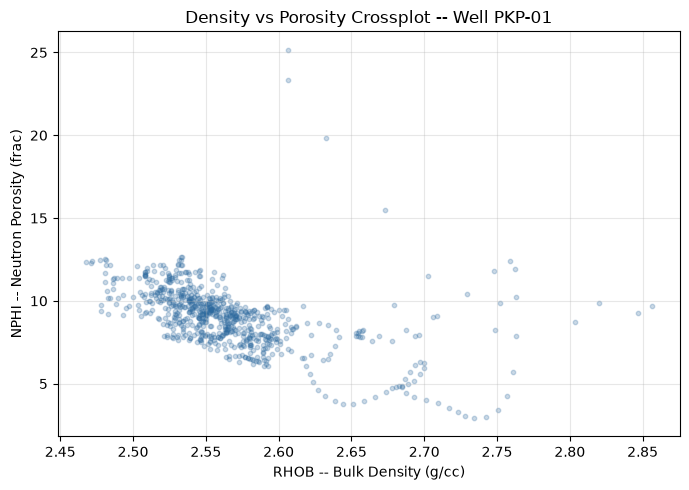

Correlation coefficient: -0.472


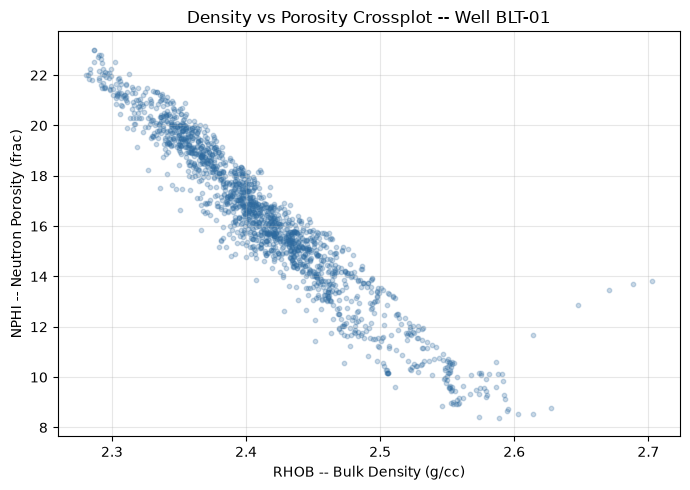

Correlation coefficient: -0.949


In [26]:
for well_id in well_list:
    if df[df['well_id'] == well_id]["bulk_density_gcc"].notna().any() and df[df['well_id'] == well_id]["porosity_pct"].notna().any():
        fig, ax = plt.subplots(figsize=(7, 5))
        ax.scatter(df[df["well_id"] == well_id]["bulk_density_gcc"], df[df['well_id'] == well_id]["porosity_pct"], alpha=0.25, s=10, color="#2d6a9f")
        ax.set_xlabel("RHOB -- Bulk Density (g/cc)")
        ax.set_ylabel("NPHI -- Neutron Porosity (frac)")
        ax.set_title(f"Density vs Porosity Crossplot -- Well {well_id}")
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        print("Correlation coefficient:", round(df[df["well_id"] == well_id]["bulk_density_gcc"].corr(df[df["well_id"] == well_id]["porosity_pct"]), 3))

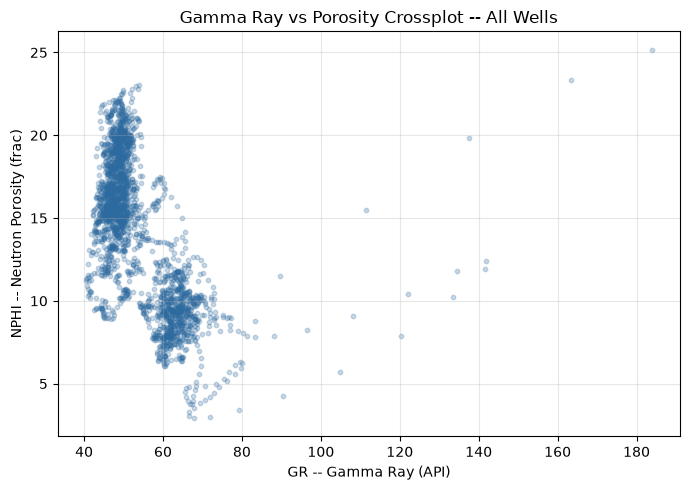

Correlation coefficient: -0.559


In [11]:
# Step 2a: Explore the relationship visually before modelling
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df["gamma_ray_api"], df["porosity_pct"], alpha=0.25, s=10, color="#2d6a9f")
ax.set_xlabel("GR -- Gamma Ray (API)")
ax.set_ylabel("NPHI -- Neutron Porosity (frac)")
ax.set_title("Gamma Ray vs Porosity Crossplot -- All Wells")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("Correlation coefficient:", round(df["gamma_ray_api"].corr(df["porosity_pct"]), 3))

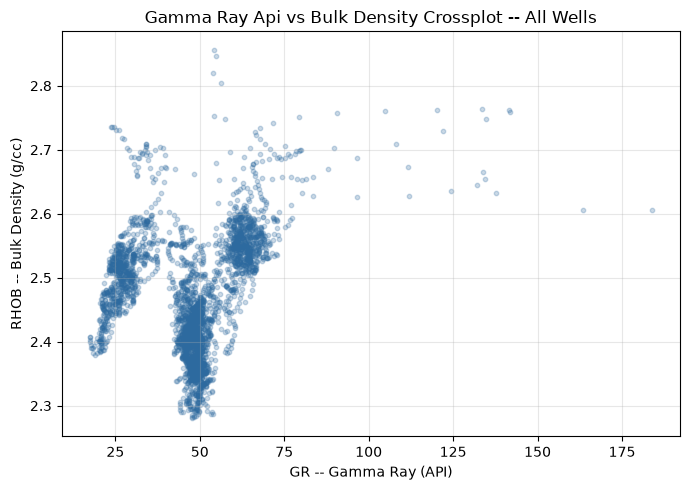

Correlation coefficient: 0.223


In [12]:
# Step 2a: Explore the relationship visually before modelling
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df["gamma_ray_api"], df["bulk_density_gcc"], alpha=0.25, s=10, color="#2d6a9f")
ax.set_xlabel("GR -- Gamma Ray (API)")
ax.set_ylabel("RHOB -- Bulk Density (g/cc)")
ax.set_title("Gamma Ray Api vs Bulk Density Crossplot -- All Wells")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("Correlation coefficient:", round(df["gamma_ray_api"].corr(df["bulk_density_gcc"]), 3))